#  tMoTe2 (Wu.F.C. 2019) #

## 计算单粒子能带H0 ##

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm as tqdm
import quspin as qs

In [15]:
# 转角 (unit in rad)
theta = np.radians(1.2)  

# MoTe2晶格常数 (unit in Angstrom)
a0 = 3.472   

# moire晶格常数 (unit in Angstrom)
aM = a0 / (2 * np.sin(theta / 2)) 

#原胞面积
A_cell= np.sqrt(3)/2 * aM**2 #unit in Angstrom^2

# 倒格矢量长度 (unit in Angstrom^-1)
bM = 4*np.pi/(np.sqrt(3)*aM) 

# 所有倒格矢量
angles = np.array([0, 1*np.pi/3, 2*np.pi/3, 3*np.pi/3, 4*np.pi/3, 5*np.pi/3]) 
b = bM * np.stack([np.cos(angles), np.sin(angles)], axis=1) 

# moire周期势V和psi （V unit in eV, psi unit in rad）
V = 8e-3  
psi = np.radians(-89.6) 

#平面波截断阶数
Nbloch = 5

# hbar^2/2m* (unit in eV·Angstrom^+2) 
h2m = 6.145    

# 隧穿幅度 （unit in eV）
w = -8.5e-3 

#高对称点晶格动量 K_t 对应 K_+ ， K_b 对应 K_-
Kt = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), -np.sin(np.pi/6)], axis=0) 
Kb = bM/np.sqrt(3) * np.stack([-np.cos(np.pi/6), +np.sin(np.pi/6)], axis=0) 

100%|██████████| 100/100 [00:13<00:00,  7.49it/s]


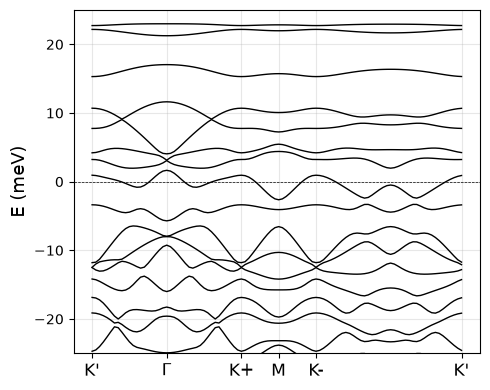

In [16]:
"""
#构造哈密顿量H0,对角项除了动量项还有上下层分别的Moire势，
#Delta = 2V sum cos(b_i cdot r + psi) = V * sum exp(1i*psi)*exp(1i*b_i * r) + exp(-1i*psi)*exp(-1i*b_i * r)
#这个含r的项的傅里叶变换给出动量空间的矩阵元<p|V|q> = V sum_i (exp(1i*psi)delta(p-q-b_i) + exp(-1i*psi)delta(p-q+b_i))
#现在要把分立的bloch模式写出来，不同的bloch模式之间应用<p|V|q>的非对角元描述，哈密顿矩阵扩张成为2(2N+1)维度，其中Nbloch是bloch模式的截断
"""
Gs = np.array([m*b[0] + n*b[2] for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
G_coord_x = np.stack([1,0]) #b0方向的坐标
G_coord_y = np.stack([0,1]) #b2方向的坐标
G_coord = np.array([(m,n) for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
lenG = len(Gs)

"""构造moire周期势 Delta_t/b """
Delta_t = np.zeros((lenG, lenG), dtype=complex)
Delta_b = np.zeros((lenG, lenG), dtype=complex)
b_allowed = [G_coord_x, G_coord_y, -G_coord_x-G_coord_y]
for i , coord in enumerate(G_coord):
    for j , bj in enumerate(b_allowed):
        coord_prime = coord - bj
        if -Nbloch <= coord_prime[0]<= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            Delta_t [i,k] = V * np.exp(+1j * psi)
            Delta_b [i,k] = V * np.exp(-1j * psi)
        coord_prime = coord + bj
        if -Nbloch <= coord_prime[0] <= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            Delta_t [i,k] = V * np.exp(-1j * psi)
            Delta_b [i,k] = V * np.exp(+1j * psi)
            
""" 构造隧穿矩阵T"""
T = np.zeros((lenG, lenG))
b_allowed_for_T = [G_coord_x-G_coord_x , G_coord_y, G_coord_x+G_coord_y]
for i , coord in enumerate(G_coord):
    for j , bj in enumerate(b_allowed_for_T):
        coord_prime = coord + bj
        if -Nbloch <= coord_prime[0]<= Nbloch and  -Nbloch <= coord_prime[1] <= Nbloch:
            k = (coord_prime[0] + Nbloch) * (2*Nbloch + 1)  + (coord_prime[1] + Nbloch)
            T [i,k] = w
        
H0_non_diag = np.block([[Delta_t, T],[T.conj().T, Delta_b]])

"""计算H0中的动能项"""
def calc_H0_diag(k, Gs, Kt, Kb):
    # 我现在的基底是bloch平面波psi_i，我的每个基底在p算符下的动量为k->k+G_i
    diagts = []
    diagbs = []
    for i, Gi in enumerate(Gs):
        diagt = -h2m * (np.linalg.norm(k  + Gi - Kt)) **2
        diagb = -h2m * (np.linalg.norm(k  + Gi - Kb)) **2
        diagts.append(diagt)
        diagbs.append(diagb)
    H0diag = np.diag(diagts + diagbs)
    return H0diag

"""高对称点路径上每一个点进行对角化"""
def kpoints(start, end, n):
    return [start + i/n * (end - start) for i in range(n)]
G = np.array([0.0, 0.0])
M = bM * np.array([-1/2, 0.0])
Kplus = bM * np.array([-1/2, +1/(2*np.sqrt(3))])
Kminus = bM * np.array([-1/2, -1/(2*np.sqrt(3))])
Kp = bM * np.array([+1/2, -1/(2*np.sqrt(3))])

knum = np.array([10,10,5,5,20]) *2
kpath = (kpoints(Kp,G,knum[0])+ kpoints(G, Kplus, knum[1]) + kpoints(Kplus, M, knum[2]) + kpoints(M, Kminus, knum[3]) + kpoints(Kminus, Kp, knum[4]))
eigvals = []
for k in tqdm.tqdm(kpath):
    H0_diag = calc_H0_diag(k, Gs, Kt, Kb)
    H0 = H0_non_diag + H0_diag
    evals, _ = np.linalg.eigh(H0)
    eigvals.append(evals)
eigvals = np.array(eigvals)   
Nk = eigvals.shape[0]         
dim = eigvals.shape[1]   
k_index = np.arange(Nk)
E_min, E_max = -25, 25
plt.figure(figsize=(5, 4))

for n in range(dim):
    E_n = eigvals[:, n]       # 第 n 条带
    if E_n.min() < E_max and E_n.max() > E_min:
        plt.plot(k_index, E_n *1000, lw=1.0, color = 'k')

kk2 = [0] + np.cumsum(knum).tolist()
kk2[-1] -= 1
kk1 = ["K'", r"$\Gamma$", "K+", "M", "K-", "K'"]
plt.xticks(kk2, kk1, fontsize=12)
plt.ylabel('E (meV)', fontsize=13)
plt.ylim(E_min, E_max)
plt.axhline(0, color='k', lw=0.5, ls='--')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


##  计算陈数 ##

100%|██████████| 21/21 [00:54<00:00,  2.61s/it]


chern_number 1.00015 band 1


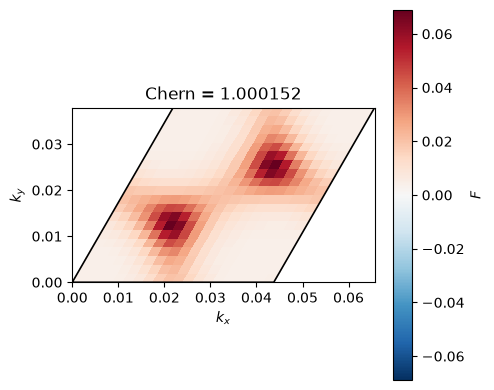

In [17]:
"""计算第一价带的陈数"""
"""现在不用六角形miniBZ，换成一个平行四边形区域计算微元上的曲率"""
"""F^hatsugai_kx_ky = arg(<u_k|u_k+dkx> * <u_k+dkx|u_k+dkx+dky> * <u_dkx+dky|u_k+dky> * <u_dky|u_k>)"""

def calc_chern (bx, by, step, band_id):
    dbx = bx/step
    dby = by/step
    
    vecs = np.zeros((step+1, step+1, dim), dtype = complex)
    for i in tq.tqdm(range(0,step+1)):
        for j in range(0,step+1):
            k = i * dbx + j * dby
            H0tot = H0_non_diag + calc_H0_diag(k, Gs, Kt, Kb)
            _, v = np.linalg.eigh(H0tot)
            vecs[i,j,:] = v[:,-band_id]
    
    F = np.zeros((step,step))
    for i in range(0,step):
        for j in range(0,step):
            vs = [vecs[i,j,:], vecs[i+1,j,:],vecs[i+1,j+1,:],vecs[i,j+1,:]]   
            ua = np.vdot(vs[0],vs[1]) 
            ub = np.vdot(vs[1],vs[2])
            uc = np.vdot(vs[2],vs[3])
            ud = np.vdot(vs[3],vs[0])
            Zi = ua*ub*uc*ud
            F[i,j] = np.angle(Zi)
    return F

def plot_F(F, b0, b1, step):
    b0 = np.asarray(b0, dtype=float).reshape(2)
    b1 = np.asarray(b1, dtype=float).reshape(2)
    I, J = np.meshgrid(np.arange(step + 1), np.arange(step + 1), indexing='ij')
    X = I * (b0[0] / step) + J * (b1[0] / step)
    Y = I * (b0[1] / step) + J * (b1[1] / step)

    vmax = np.abs(F).max() or 1.0

    fig, ax = plt.subplots(figsize=(5, 4))
    mesh = ax.pcolormesh(X, Y, F.T, cmap='RdBu_r',
                         vmin=-vmax, vmax=vmax, shading='flat')

    # BZ 边界
    corners = np.array([[0, 0], b0, b0 + b1, b1, [0, 0]])
    ax.plot(corners[:, 0], corners[:, 1], 'k-', lw=1.2)

    fig.colorbar(mesh, ax=ax, label=r'$F$')
    ax.set_aspect('equal')
    ax.set_xlabel(r'$k_x$'); ax.set_ylabel(r'$k_y$')
    ax.set_title(f'Chern = {F.sum()/(2*np.pi):.6f}')
    plt.tight_layout(); plt.show()

step = 20
band_id = 1
F = calc_chern(b[0], b[1], step, band_id)
ch = np.sum(F[:step, :step]) / (2 * np.pi)
print(f"chern_number {ch:.5f} band {band_id}")
plot_F(F,b[0],b[1], step)

##  H0的周期性 ##

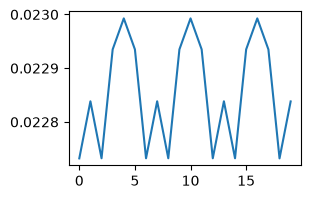

In [21]:
"""验证哈密顿量沿着某个方向在某个范围是否有周期性"""
path = kpoints(-5*Kp,5*Kp,20)
etot = []
for  i,k in enumerate(path):
    H0 = H0_non_diag + calc_H0_diag(k, Gs, Kt, Kb)
    e,v = np.linalg.eigh(H0)
    etot.append(e[-1])

plt.figure(figsize=(3, 2))
plt.plot(etot)

##  相互作用投影与ED ##

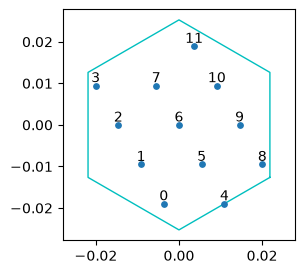

(-0.03679189197628758+0.005825575234773428j)


In [22]:
"""计算库伦相互作用下的精确对角化能谱"""
"""
沿着实空间基矢量L0和L1方向复制N*M次形成原胞cluster(N*M个原胞组成的平行四边形)，
这等价于在mini BZ中采样N*M个动量点，用mBZ的六角形区域模出来N*M个采样点。

实空间上的库仑相互作用V翻译到动量空间的一个矩阵元就是sum_{q} { V<k1|exp(iq*r1)|k3> <k2|exp(i(-q)*r2)|k4> } ，
一个电子在r1处和另一个电子在r2处交换了一个动量q。

由于我们的单粒子哈密顿量用的是截断的平面波基矢量因此动量q包含了两部分，
一部分是mBZ中采样点之间交换的小动量部分 [q]，另一部分是mBZ的晶格动量G，q = [q]+G，
[q]可以看成动量q模掉整数个mBZ晶格动量G后到mBZ的余数。

矩阵元可以写成sum_{q} { {V(q)} * {delta_{k1,k3+[q]} delta_{k2,k4-[q]}} * F(k1,k3,G_{k3+q}) * F(k2,k4, G_{k4-q}) }
delta函数直接翻译了<k1|exp(i[q]*r)|k3>矩阵元的小动量部分，q的晶格部分(G_{k3+q}) (因为exp(iq*r)|k3>作用给出k3+q这个因子)包含在形状因子F中，
所以F = sum_{G'}u*_{k1,G_{k3+q} + G'} u_{k3,G'} 这里的u_{k,G}是单粒子波函数在k采样点的G分量的系数，这个求和的包含了所有从G'传递G'+G_{k3+q}的情况的振幅
"""
N1 = 3 #实空间30°方向的原胞数量
N2 = 4 #实空间-90°方向的原胞数量
N = N1*N2 #总采样数量
band_id = 1 #chern带标记


"""生成采样点"""
ks = np.array([i*b[0]/N1 + j*b[2]/N2 for i in range(-N1,N1+1) for j in range(-N2,N2+1)])
kmesh = []
for i, k in enumerate(ks):
    if (-bM/2 < k[0] <= bM/2 and
        -bM/np.sqrt(3) < k[1] + k[0]/np.sqrt(3) <= bM/np.sqrt(3) and
        -bM/np.sqrt(3) <= k[1] - k[0]/np.sqrt(3) < bM/np.sqrt(3)):
        #mask取一个六角形BZ,左边允许压线，右边不允许
        kmesh.append(k) 

kmesh = np.array(kmesh)
assert len(kmesh) == N #检查生成的采样点数量
hex_vertices = np.array([(b[0]-b[2])/3,(2*b[0]+b[2])/3,(b[0]+2*b[2])/3,(-b[0]+b[2])/3,(-2*b[0]-b[2])/3,(-b[0]-2*b[2])/3,(b[0]-b[2])/3])
plt.figure(figsize=(3, 3))
plt.scatter(kmesh[:, 0], kmesh[:, 1], s=15, zorder=2)
plt.plot(hex_vertices[:, 0], hex_vertices[:, 1], 'c-', lw=1, zorder=1)
for idx, (x, y) in enumerate(kmesh):
    plt.annotate(str(idx), (x, y), fontsize=10, ha='center', va='bottom')
plt.axis('equal')
plt.show()

"""计算每个k采样点上的单粒子波函数"""
kvecs = np.zeros((N, dim), dtype = complex)#每个采样点存一个波函数向量
for i,k in enumerate(kmesh):
    H0 = H0_non_diag+ calc_H0_diag(k,Gs,Kt,Kb)
    _, eigvec = np.linalg.eigh(H0)
    kvecs[i,:] = eigvec[:,-band_id]



"""计算库伦相互作用矩阵元"""
cons = 14.4 #2pi*e^2/epsilon (unit in eV * Angstrom)

#晶格动量的转移可以是两个对角格点相减，因此会是2倍大小的Gs
Gs = np.array([m*b[0] + n*b[2] for m in range(-Nbloch, Nbloch+1) for n in range(-Nbloch, Nbloch+1)])
G_coord_ext = np.array([(m,n) for m in range(-2*Nbloch, 2*Nbloch+1) for n in range(-2*Nbloch, 2*Nbloch+1)])
Gs_ext = np.array([m*b[0] + n*b[2] for m in range(-2*Nbloch, 2*Nbloch+1) for n in range(-2*Nbloch, 2*Nbloch+1)])
A = A_cell * N

def calc_interaction(kvecs,i,j,k,l):
    #限制q在一个mBZ中，如果q匹配成功，那么遍历所有的G,去匹配G
    k1 = kmesh[i]
    k2 = kmesh[j]
    k3 = kmesh[k]
    k4 = kmesh[l]
    if np.linalg.norm((k1 - k3) - (k4 - k2)) < 1e-8:
        #遍历所有的截断晶格向量
        V_int = 0
        for g_coord in G_coord_ext:
            g = g_coord[0]*b[0] + g_coord[1]*b[1]
            cons_q = cons/np.linalg.norm(k1 - k3 + g) #转移动量包含mBZ内部的小动量和大晶格动量g
            F1 = calc_form_factor(kvecs[i,:],kvecs[k,:], g_coord)
            F2 = calc_form_factor(kvecs[j,:],kvecs[l,:], -g_coord)
            V_int += cons_q * F1 * F2
        return V_int/A
    else:
        return 0

def coord_to_index(x,y):
    idx = Nbloch*(x+Nbloch) + y+Nbloch
    return idx
    
def calc_form_factor(vec1,vec2,g_coord):
    #form factor需要按照层内匹配去计算
    x1 = max([-Nbloch + g_coord[0] , -Nbloch])
    x2 = min([+Nbloch + g_coord[0] , +Nbloch])
    y1 = max([-Nbloch + g_coord[1] , -Nbloch])
    y2 = min([+Nbloch + g_coord[1] , +Nbloch])
    
    ff = 0
    for xi in range(x1,x2+1):
        for yi in range(y1,y2+1):
            ff += vec1[coord_to_index(xi,yi)].conj() * vec2[coord_to_index(xi,yi)] #top 层
            ff +=vec1[coord_to_index(xi,yi)+(2*Nbloch+1)**2].conj() * vec2[coord_to_index(xi,yi)+(2*Nbloch+1)**2] #bottom层
    return ff
    
"""
for i in range(0,N):
    for j in range(0,N):
        if j == i:
            continue
        for k in range(0,N):
            if k == j or k == i :
                continue
            for l in range(0,N):
                if l == k or l ==j or l == i:
                    continue
                x = calc_interaction(kvecs,l,k,j,i)
                if x != 0:
                    print(x)
"""
print(calc_interaction(kvecs,11,6,10,7))